# BTC Dynamic Hedging Backtest via Kalshi Event Contracts

This notebook backtests a **dynamic hedging strategy** that pairs a BTC spot position with Kalshi binary event contracts. The core idea: use Black-Scholes to estimate the "fair" probability that BTC hits a strike, compare it to Kalshi's implied probability, and trade the mispricing.

**Three strategies are compared:**
- **Strategy A** — Unhedged BTC (buy & hold)
- **Strategy B** — Static Hedge (BTC + short Kalshi Yes at entry, hold to expiry)
- **Strategy C** — Dynamic Hedge (BTC + signal-based Kalshi trading on mispricing)

**Four time periods / markets are tested:**
1. **2024** — Will BTC max reach $100K+ by Dec 31, 2024? (thresholds: 25/15/5%)
2. **Aug 2025** — Will BTC max reach $130K+ in August 2025? (thresholds: 15/5/2%)
3. **Nov–Dec 2025** — Will BTC close above $100K on Dec 31, 2025? (thresholds: 15/5/2%)
4. **Jan 2026** — Will BTC max reach $100K+ by Jan 31, 2026? (thresholds: 15/5/2%)

Each scenario reports results **without fees** and **with Kalshi fees** (7% of notional × p(1−p) per trade).

---
## Setup & Imports

In [19]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

---
## Core Functions

These functions are shared across all three scenarios.

In [20]:
def black_scholes_probability(current_price, strike, days_to_expiry, volatility=0.60):
    """
    Estimate P(BTC > strike at expiry) using a simplified Black-Scholes model.
    
    Uses d2 = [ln(S/K) - 0.5*sigma^2*T] / (sigma*sqrt(T)), with r=0
    (risk-neutral assumption; crypto has no traditional risk-free rate).
    
    Parameters
    ----------
    current_price : float  — Current BTC spot price
    strike        : float  — Strike price for the event contract
    days_to_expiry: float  — Days remaining until contract expiry
    volatility    : float  — Annualized volatility (default 60% for crypto)
    
    Returns
    -------
    float — Probability (0 to 1) that BTC finishes above the strike
    """
    if days_to_expiry <= 0:
        return 1.0 if current_price > strike else 0.0
    
    T = days_to_expiry / 365.0
    d2 = (np.log(current_price / strike) - 0.5 * volatility**2 * T) / (volatility * np.sqrt(T))
    return norm.cdf(d2)


def generate_signals(df, strong_thresh, weak_thresh, neutral_thresh):
    """
    Generate scaled trading signals based on BSM vs Kalshi mispricing.
    
    Signal mapping:
      +2  = strong buy Yes   (mispricing > strong_thresh)
      +1  = weak buy Yes     (mispricing > weak_thresh)
       0  = neutral          (|mispricing| < neutral_thresh)
      -1  = weak short Yes   (mispricing < -weak_thresh)
      -2  = strong short Yes (mispricing < -strong_thresh)
    
    Between thresholds, the previous signal is held (hysteresis).
    """
    df = df.copy()
    df['signal'] = 0
    
    for i in range(1, len(df)):
        m = df.iloc[i]['prob_mispricing']
        if m > strong_thresh:
            df.iloc[i, df.columns.get_loc('signal')] = 2
        elif m > weak_thresh:
            df.iloc[i, df.columns.get_loc('signal')] = 1
        elif m < -strong_thresh:
            df.iloc[i, df.columns.get_loc('signal')] = -2
        elif m < -weak_thresh:
            df.iloc[i, df.columns.get_loc('signal')] = -1
        elif abs(m) < neutral_thresh:
            df.iloc[i, df.columns.get_loc('signal')] = 0
        else:  # hold previous signal (hysteresis zone)
            df.iloc[i, df.columns.get_loc('signal')] = df.iloc[i-1]['signal']
    
    df['position_change'] = df['signal'].diff()
    df['trade'] = (df['position_change'] != 0) & (df['position_change'].notna())
    return df


def compute_dynamic_pnl(df, contracts=100):
    """
    Compute the Kalshi-side P&L for Strategy C (dynamic hedge).
    
    Returns (pnl_no_fees, pnl_with_fees, total_fees, num_trades).
    """
    kalshi_pnl = 0.0
    position = 0
    entry_price = 0.0
    last_market_price = df.iloc[-1]['market_price']
    
    for i in range(1, len(df)):
        current_signal = df.iloc[i]['signal']
        current_price = df.iloc[i]['market_price']
        
        if position != current_signal:
            if position != 0:
                close_pnl = (current_price - entry_price) * position * contracts
                kalshi_pnl += close_pnl
            position = current_signal
            entry_price = current_price
    
    # Close any remaining position at end
    if position != 0:
        kalshi_pnl += (last_market_price - entry_price) * position * contracts
    
    # Kalshi fee: 7% * contracts * p*(1-p), rounded up to nearest cent, per trade
    total_fees = sum([
        np.ceil(0.07 * contracts * df.iloc[i]['market_price'] * (1 - df.iloc[i]['market_price']) * 100) / 100
        for i in range(len(df)) if df.iloc[i]['trade']
    ])
    
    num_trades = int(df['trade'].sum())
    return kalshi_pnl, kalshi_pnl - total_fees, total_fees, num_trades


def run_backtest(kalshi_csv, btc_csv, kalshi_col, strike, expiry_date,
                 strong_thresh, weak_thresh, neutral_thresh,
                 initial_capital=10000, contracts=100, volatility=0.60):
    """
    Full backtest pipeline for one scenario.
    
    Returns a dict with all results + the merged DataFrame.
    """
    # --- Load Kalshi data ---
    kalshi = pd.read_csv(kalshi_csv)
    kalshi['timestamp'] = pd.to_datetime(kalshi['timestamp']).dt.tz_localize(None)
    kalshi['market_price'] = kalshi[kalshi_col] / 100  # cents → probability
    kalshi = kalshi[['timestamp', 'market_price']].dropna()
    
    # --- Load BTC 1-min data ---
    btc = pd.read_csv(btc_csv)
    btc['timestamp'] = pd.to_datetime(btc['timestamp']).dt.tz_localize(None)
    btc = btc[['timestamp', 'close', 'high', 'low']].copy()
    btc.columns = ['timestamp', 'btc_price', 'btc_high', 'btc_low']
    
    # --- Merge (forward-fill Kalshi onto BTC timeline) ---
    df = pd.merge_asof(
        btc.sort_values('timestamp'),
        kalshi.sort_values('timestamp'),
        on='timestamp',
        direction='backward'
    )
    df = df[df['market_price'].notna()].copy()
    
    # --- BSM probability & mispricing ---
    expiry = pd.Timestamp(expiry_date)
    df['days_to_expiry'] = (expiry - df['timestamp']).dt.total_seconds() / 86400
    df['actual_prob'] = df.apply(
        lambda r: black_scholes_probability(r['btc_price'], strike, r['days_to_expiry'], volatility),
        axis=1
    )
    df['implied_prob'] = df['market_price']  # Kalshi price = implied probability
    df['prob_mispricing'] = df['actual_prob'] - df['implied_prob']
    
    # --- Generate signals ---
    df = generate_signals(df, strong_thresh, weak_thresh, neutral_thresh)
    
    # --- Strategy A: Unhedged BTC (buy & hold) ---
    first_btc = df.iloc[0]['btc_price']
    last_btc = df.iloc[-1]['btc_price']
    btc_return = (last_btc - first_btc) / first_btc
    pnl_a = initial_capital * btc_return
    
    # --- Strategy B: Static Hedge ---
    first_mkt = df.iloc[0]['market_price']
    last_mkt = df.iloc[-1]['market_price']
    kalshi_pnl_b = (first_mkt - last_mkt) * contracts  # short Yes at entry, close at end
    # Fee on static hedge: entry + exit = 2 trades
    fee_entry = np.ceil(0.07 * contracts * first_mkt * (1 - first_mkt) * 100) / 100
    fee_exit  = np.ceil(0.07 * contracts * last_mkt  * (1 - last_mkt)  * 100) / 100
    static_fees = fee_entry + fee_exit
    pnl_b_no_fee = pnl_a + kalshi_pnl_b
    pnl_b_fee    = pnl_a + kalshi_pnl_b - static_fees
    
    # --- Strategy C: Dynamic Hedge ---
    kalshi_c_no_fee, kalshi_c_fee, total_fees_c, num_trades = compute_dynamic_pnl(df, contracts)
    pnl_c_no_fee = pnl_a + kalshi_c_no_fee
    pnl_c_fee    = pnl_a + kalshi_c_fee
    
    return {
        'df': df,
        'first_btc': first_btc, 'last_btc': last_btc, 'btc_return': btc_return,
        'first_mkt': first_mkt, 'last_mkt': last_mkt,
        'pnl_a': pnl_a,
        'kalshi_pnl_b': kalshi_pnl_b, 'static_fees': static_fees,
        'pnl_b_no_fee': pnl_b_no_fee, 'pnl_b_fee': pnl_b_fee,
        'kalshi_c_no_fee': kalshi_c_no_fee, 'kalshi_c_fee': kalshi_c_fee,
        'total_fees_c': total_fees_c, 'num_trades': num_trades,
        'pnl_c_no_fee': pnl_c_no_fee, 'pnl_c_fee': pnl_c_fee,
        'initial_capital': initial_capital, 'contracts': contracts,
        'strong_thresh': strong_thresh, 'weak_thresh': weak_thresh, 'neutral_thresh': neutral_thresh,
    }


def print_results(res, title):
    """Pretty-print the results for one scenario."""
    cap = res['initial_capital']
    print(f"{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    
    df = res['df']
    print(f"\n  Data: {len(df):,} aligned 1-min bars")
    print(f"  Range: {df['timestamp'].min()} → {df['timestamp'].max()}")
    print(f"  Mean implied prob:  {df['implied_prob'].mean():.2%}")
    print(f"  Mean BSM prob:      {df['actual_prob'].mean():.2%}")
    print(f"  Mean mispricing:    {df['prob_mispricing'].mean():.2%}")
    print(f"  Signal thresholds:  strong={res['strong_thresh']:.0%}  weak={res['weak_thresh']:.0%}  neutral=±{res['neutral_thresh']:.0%}")
    print(f"  Total trades:       {res['num_trades']}")
    
    print(f"\n  {'STRATEGY A: Unhedged BTC (Buy & Hold)':}")
    print(f"    Entry: ${res['first_btc']:,.2f}  →  Exit: ${res['last_btc']:,.2f}")
    print(f"    BTC Return: {res['btc_return']:.2%}")
    print(f"    P&L: ${res['pnl_a']:,.2f}  ({res['pnl_a']/cap:.2%})")
    
    print(f"\n  {'STRATEGY B: Static Hedge':}")
    print(f"    Kalshi entry (short Yes): {res['first_mkt']:.2%}  →  exit: {res['last_mkt']:.2%}")
    print(f"    Kalshi P&L:  ${res['kalshi_pnl_b']:,.2f}")
    print(f"    Without fees: ${res['pnl_b_no_fee']:,.2f}  ({res['pnl_b_no_fee']/cap:.2%})")
    print(f"    With fees:    ${res['pnl_b_fee']:,.2f}  ({res['pnl_b_fee']/cap:.2%})   [fees: ${res['static_fees']:,.2f}]")
    
    print(f"\n  {'STRATEGY C: Dynamic Hedge':}")
    print(f"    Kalshi P&L (no fees):  ${res['kalshi_c_no_fee']:,.2f}")
    print(f"    Total fees:            ${res['total_fees_c']:,.2f}  ({res['num_trades']} trades)")
    print(f"    Without fees: ${res['pnl_c_no_fee']:,.2f}  ({res['pnl_c_no_fee']/cap:.2%})")
    print(f"    With fees:    ${res['pnl_c_fee']:,.2f}  ({res['pnl_c_fee']/cap:.2%})")
    
    print(f"\n  {'— Summary Table —':}")
    summary = pd.DataFrame({
        'Strategy': ['A: Unhedged', 'B: Static Hedge', 'C: Dynamic Hedge'],
        'P&L (no fees)': [res['pnl_a'], res['pnl_b_no_fee'], res['pnl_c_no_fee']],
        'P&L (with fees)': [res['pnl_a'], res['pnl_b_fee'], res['pnl_c_fee']],
        'Return (no fees)': [f"{res['pnl_a']/cap:.2%}", f"{res['pnl_b_no_fee']/cap:.2%}", f"{res['pnl_c_no_fee']/cap:.2%}"],
        'Return (with fees)': [f"{res['pnl_a']/cap:.2%}", f"{res['pnl_b_fee']/cap:.2%}", f"{res['pnl_c_fee']/cap:.2%}"],
    })
    print(summary.to_string(index=False))
    return summary


def plot_scenario(res, title):
    """Visualize BTC price, probabilities, mispricing, and signals for one scenario."""
    df = res['df']
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    # Panel 1: BTC price
    axes[0].plot(df['timestamp'], df['btc_price'], color='#f7931a', linewidth=0.6)
    axes[0].set_ylabel('BTC Price ($)')
    axes[0].set_title('BTC Spot Price')
    
    # Panel 2: Implied vs Actual probability
    axes[1].plot(df['timestamp'], df['implied_prob'], label='Kalshi Implied', alpha=0.8, linewidth=0.6)
    axes[1].plot(df['timestamp'], df['actual_prob'], label='BSM Actual', alpha=0.8, linewidth=0.6)
    axes[1].set_ylabel('Probability')
    axes[1].set_title('Implied vs BSM Probability')
    axes[1].legend()
    
    # Panel 3: Mispricing + signal
    axes[2].plot(df['timestamp'], df['prob_mispricing'], color='gray', alpha=0.5, linewidth=0.5, label='Mispricing')
    axes[2].axhline(y=res['strong_thresh'], color='green', linestyle='--', alpha=0.5, label=f"Strong ({res['strong_thresh']:.0%})")
    axes[2].axhline(y=res['weak_thresh'], color='green', linestyle=':', alpha=0.4)
    axes[2].axhline(y=-res['strong_thresh'], color='red', linestyle='--', alpha=0.5)
    axes[2].axhline(y=-res['weak_thresh'], color='red', linestyle=':', alpha=0.4)
    axes[2].axhline(y=0, color='black', linewidth=0.5)
    
    # Color-code signal regions
    signal_colors = {2: 'green', 1: 'lightgreen', 0: 'white', -1: 'lightsalmon', -2: 'red'}
    for sig_val, color in signal_colors.items():
        if color == 'white':
            continue
        mask = df['signal'] == sig_val
        if mask.any():
            axes[2].fill_between(df['timestamp'], df['prob_mispricing'].min(), df['prob_mispricing'].max(),
                                 where=mask, alpha=0.1, color=color)
    
    axes[2].set_ylabel('Mispricing (BSM - Kalshi)')
    axes[2].set_title('Probability Mispricing & Trading Signals')
    axes[2].set_xlabel('Date')
    axes[2].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

---
## Scenario 1: 2024 — Will BTC max reach $100K+ by Dec 31, 2024?

- **Kalshi market:** `btcmaxy-24dec31` (BTC yearly max)
- **Strike:** $100,000
- **Expiry:** December 31, 2024
- **BTC data:** 1-min bars from 2024
- **Thresholds:** strong=25%, weak=15%, neutral=5% (wider bands due to higher uncertainty)

In [21]:
res_2024 = run_backtest(
    kalshi_csv='kalshi-price-history-btcmaxy-24dec31-minute.csv',
    btc_csv='BTC_1min_2024.csv',
    kalshi_col='$100000 or above',
    strike=100000,
    expiry_date='2024-12-31',
    strong_thresh=0.25,
    weak_thresh=0.15,
    neutral_thresh=0.05,
)

summary_2024 = print_results(res_2024, 'SCENARIO 1: 2024 — BTC Max ≥ $100K by Dec 31, 2024')

  SCENARIO 1: 2024 — BTC Max ≥ $100K by Dec 31, 2024

  Data: 250,326 aligned 1-min bars
  Range: 2024-04-24 16:14:00 → 2024-12-30 22:39:00
  Mean implied prob:  23.47%
  Mean BSM prob:      13.94%
  Mean mispricing:    -9.53%
  Signal thresholds:  strong=25%  weak=15%  neutral=±5%
  Total trades:       221

  STRATEGY A: Unhedged BTC (Buy & Hold)
    Entry: $64,727.88  →  Exit: $92,947.27
    BTC Return: 43.60%
    P&L: $4,359.70  (43.60%)

  STRATEGY B: Static Hedge
    Kalshi entry (short Yes): 78.18%  →  exit: 28.00%
    Kalshi P&L:  $50.18
    Without fees: $4,409.88  (44.10%)
    With fees:    $4,407.26  (44.07%)   [fees: $2.62]

  STRATEGY C: Dynamic Hedge
    Kalshi P&L (no fees):  $318.62
    Total fees:            $323.33  (221 trades)
    Without fees: $4,678.32  (46.78%)
    With fees:    $4,354.99  (43.55%)

  — Summary Table —
        Strategy  P&L (no fees)  P&L (with fees) Return (no fees) Return (with fees)
     A: Unhedged    4359.696316      4359.696316           43.

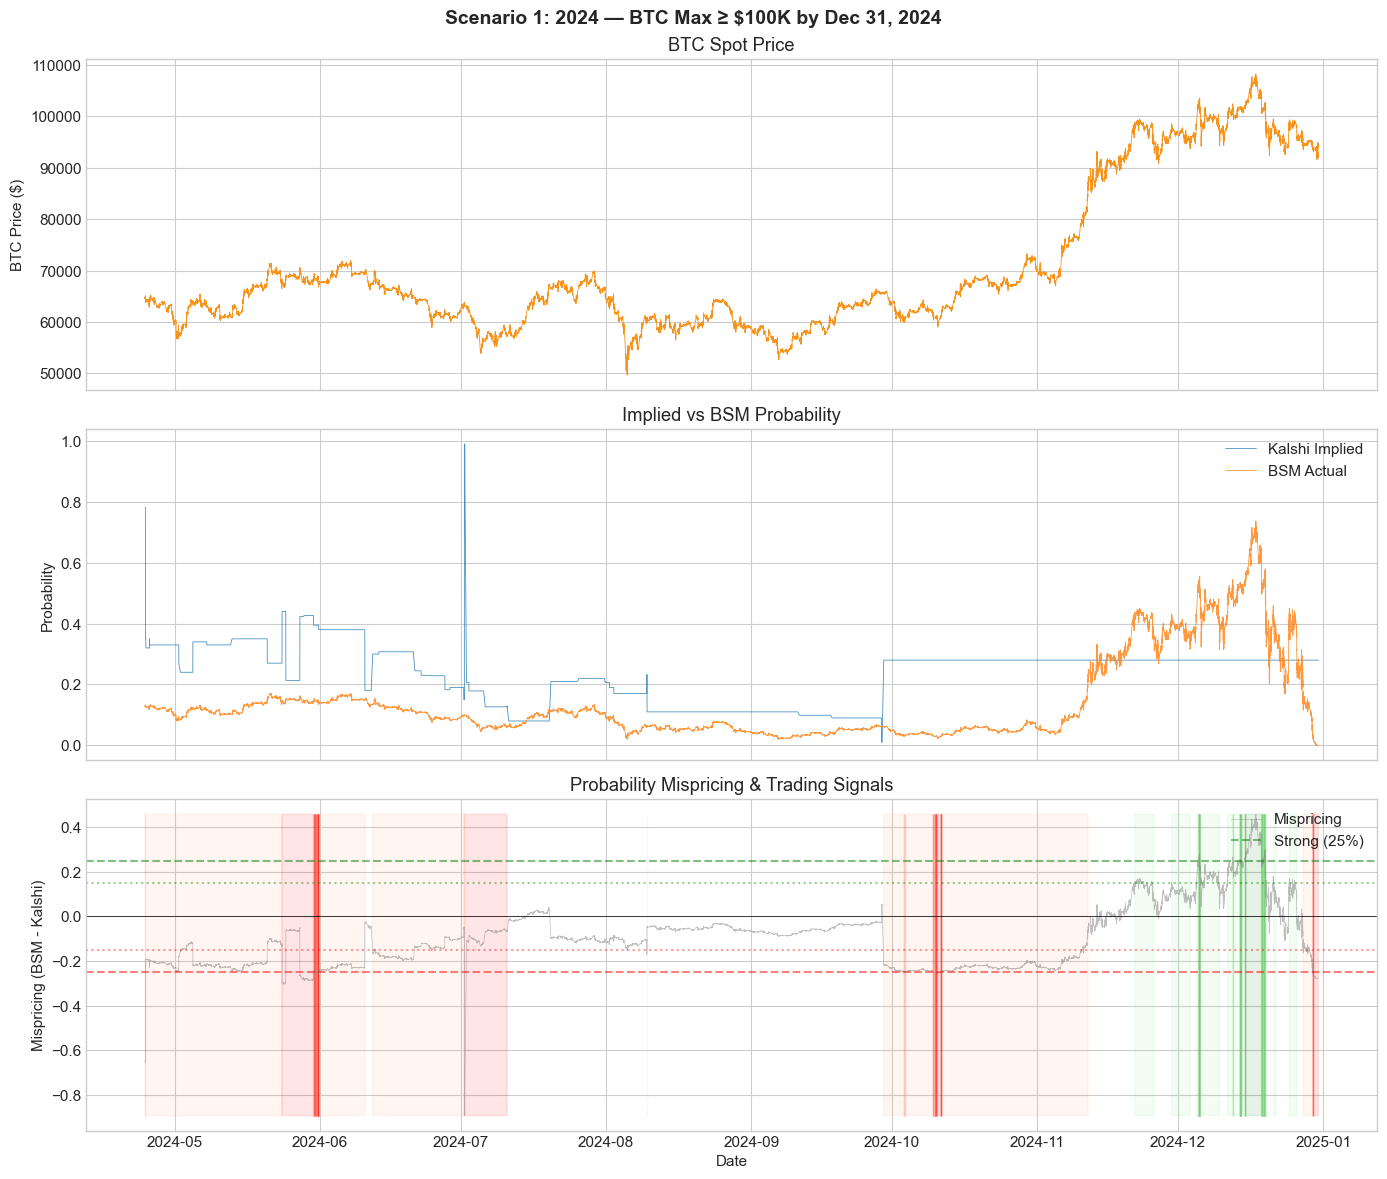

In [22]:
plot_scenario(res_2024, 'Scenario 1: 2024 — BTC Max ≥ $100K by Dec 31, 2024')

---
## Scenario 2: Aug 2025 — Will BTC max reach $130K+ in August 2025?

- **Kalshi market:** `kxbtcmaxm-aug25` (BTC monthly max)
- **Strike:** $130,000
- **Expiry:** August 31, 2025
- **BTC data:** 1-min bars from 2025
- **Thresholds:** strong=15%, weak=5%, neutral=2%

In [23]:
res_aug25 = run_backtest(
    kalshi_csv='kalshi-price-history-kxbtcmaxm-aug25-minute.csv',
    btc_csv='BTC_1min_2025.csv',
    kalshi_col='$130000 or above',
    strike=130000,
    expiry_date='2025-08-31',
    strong_thresh=0.15,
    weak_thresh=0.05,
    neutral_thresh=0.02,
)

summary_aug25 = print_results(res_aug25, 'SCENARIO 2: Aug 2025 — BTC Max ≥ $130K in August 2025')

  SCENARIO 2: Aug 2025 — BTC Max ≥ $130K in August 2025

  Data: 169,000 aligned 1-min bars
  Range: 2025-07-16 05:00:00 → 2025-12-31 22:39:00
  Mean implied prob:  91.38%
  Mean BSM prob:      5.13%
  Mean mispricing:    -86.25%
  Signal thresholds:  strong=15%  weak=5%  neutral=±2%
  Total trades:       5

  STRATEGY A: Unhedged BTC (Buy & Hold)
    Entry: $117,877.21  →  Exit: $87,873.55
    BTC Return: -25.45%
    P&L: $-2,545.33  (-25.45%)

  STRATEGY B: Static Hedge
    Kalshi entry (short Yes): 21.23%  →  exit: 99.00%
    Kalshi P&L:  $-77.77
    Without fees: $-2,623.10  (-26.23%)
    With fees:    $-2,624.35  (-26.24%)   [fees: $1.25]

  STRATEGY C: Dynamic Hedge
    Kalshi P&L (no fees):  $2.01
    Total fees:            $5.00  (5 trades)
    Without fees: $-2,543.32  (-25.43%)
    With fees:    $-2,548.32  (-25.48%)

  — Summary Table —
        Strategy  P&L (no fees)  P&L (with fees) Return (no fees) Return (with fees)
     A: Unhedged   -2545.331706     -2545.331706       

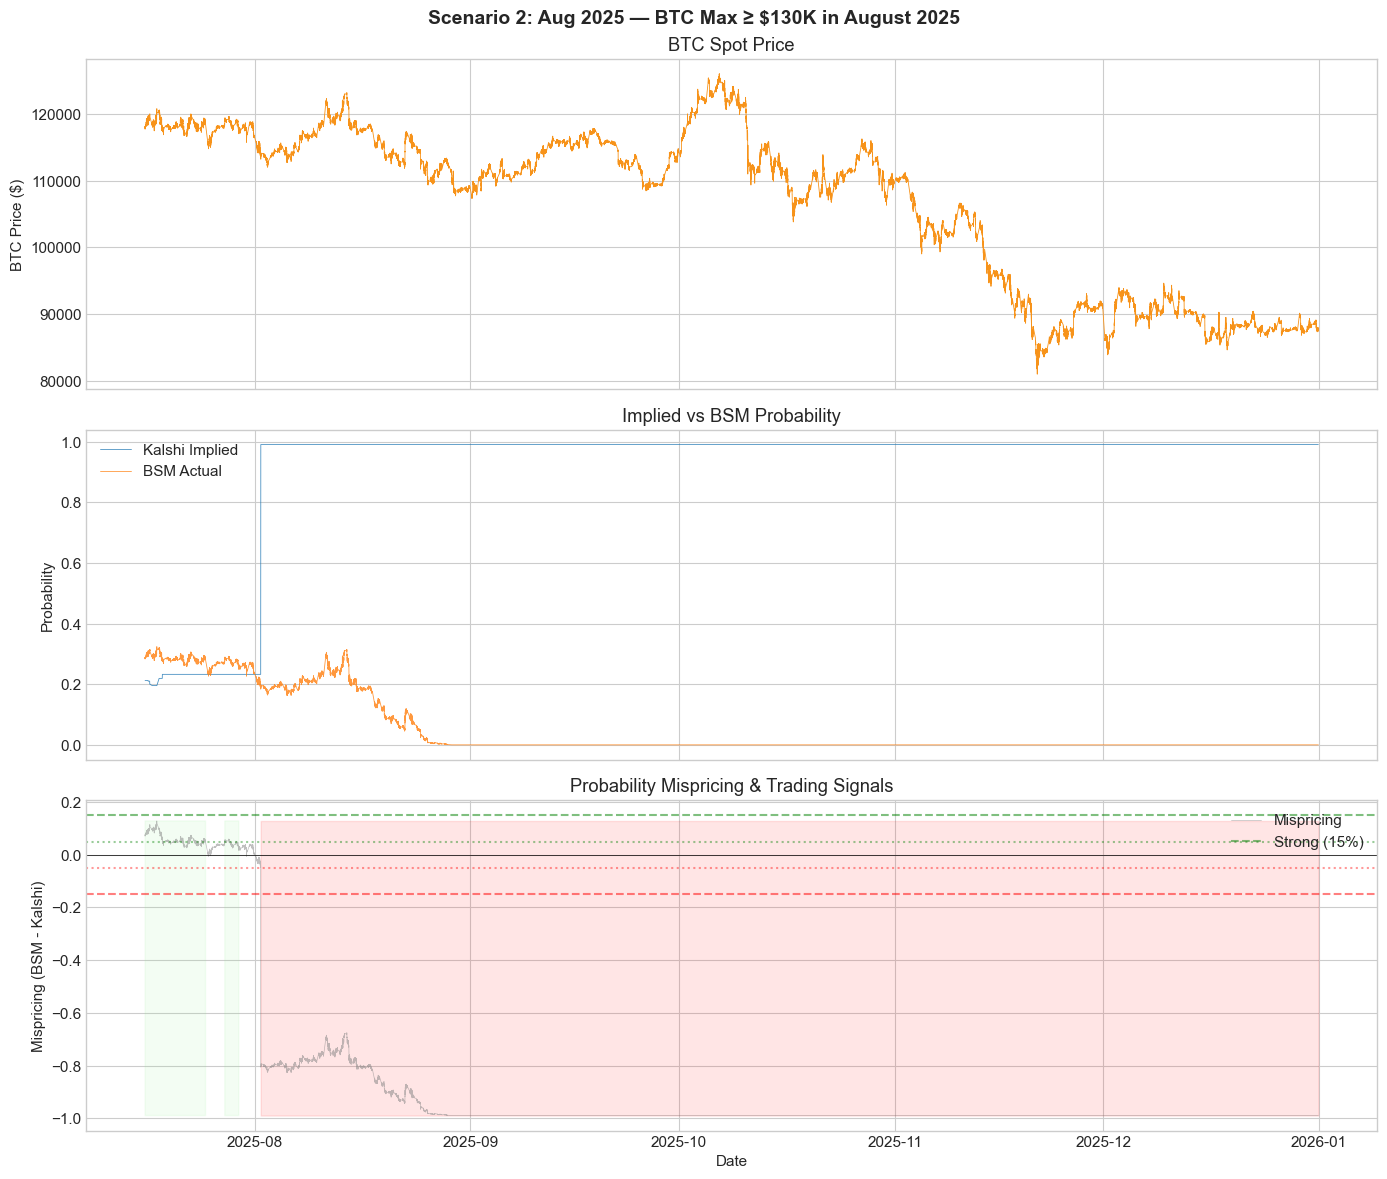

In [24]:
plot_scenario(res_aug25, 'Scenario 2: Aug 2025 — BTC Max ≥ $130K in August 2025')

---
## Scenario 3: Nov–Dec 2025 — Will BTC close above $100K on Dec 31, 2025?

- **Kalshi market:** `kxbtc2025100-25dec31` (BTC year-end close)
- **Strike:** $100,000
- **Expiry:** December 31, 2025
- **BTC data:** 1-min bars from 2025
- **Thresholds:** strong=15%, weak=5%, neutral=2%

In [25]:
res_dec25 = run_backtest(
    kalshi_csv='kalshi-price-history-kxbtc2025100-25dec31-minute.csv',
    btc_csv='BTC_1min_2025.csv',
    kalshi_col='Above $100000',
    strike=100000,
    expiry_date='2025-12-31',
    strong_thresh=0.15,
    weak_thresh=0.05,
    neutral_thresh=0.02,
)

summary_dec25 = print_results(res_dec25, 'SCENARIO 3: Nov–Dec 2025 — BTC Close > $100K on Dec 31, 2025')

  SCENARIO 3: Nov–Dec 2025 — BTC Close > $100K on Dec 31, 2025

  Data: 35,000 aligned 1-min bars
  Range: 2025-11-27 06:00:00 → 2025-12-31 22:39:00
  Mean implied prob:  35.09%
  Mean BSM prob:      15.29%
  Mean mispricing:    -19.81%
  Signal thresholds:  strong=15%  weak=5%  neutral=±2%
  Total trades:       525

  STRATEGY A: Unhedged BTC (Buy & Hold)
    Entry: $91,137.72  →  Exit: $87,873.55
    BTC Return: -3.58%
    P&L: $-358.16  (-3.58%)

  STRATEGY B: Static Hedge
    Kalshi entry (short Yes): 58.66%  →  exit: 80.00%
    Kalshi P&L:  $-21.34
    Without fees: $-379.50  (-3.79%)
    With fees:    $-382.33  (-3.82%)   [fees: $2.83]

  STRATEGY C: Dynamic Hedge
    Kalshi P&L (no fees):  $2,827.21
    Total fees:            $824.72  (525 trades)
    Without fees: $2,469.05  (24.69%)
    With fees:    $1,644.33  (16.44%)

  — Summary Table —
        Strategy  P&L (no fees)  P&L (with fees) Return (no fees) Return (with fees)
     A: Unhedged    -358.157961      -358.157961     

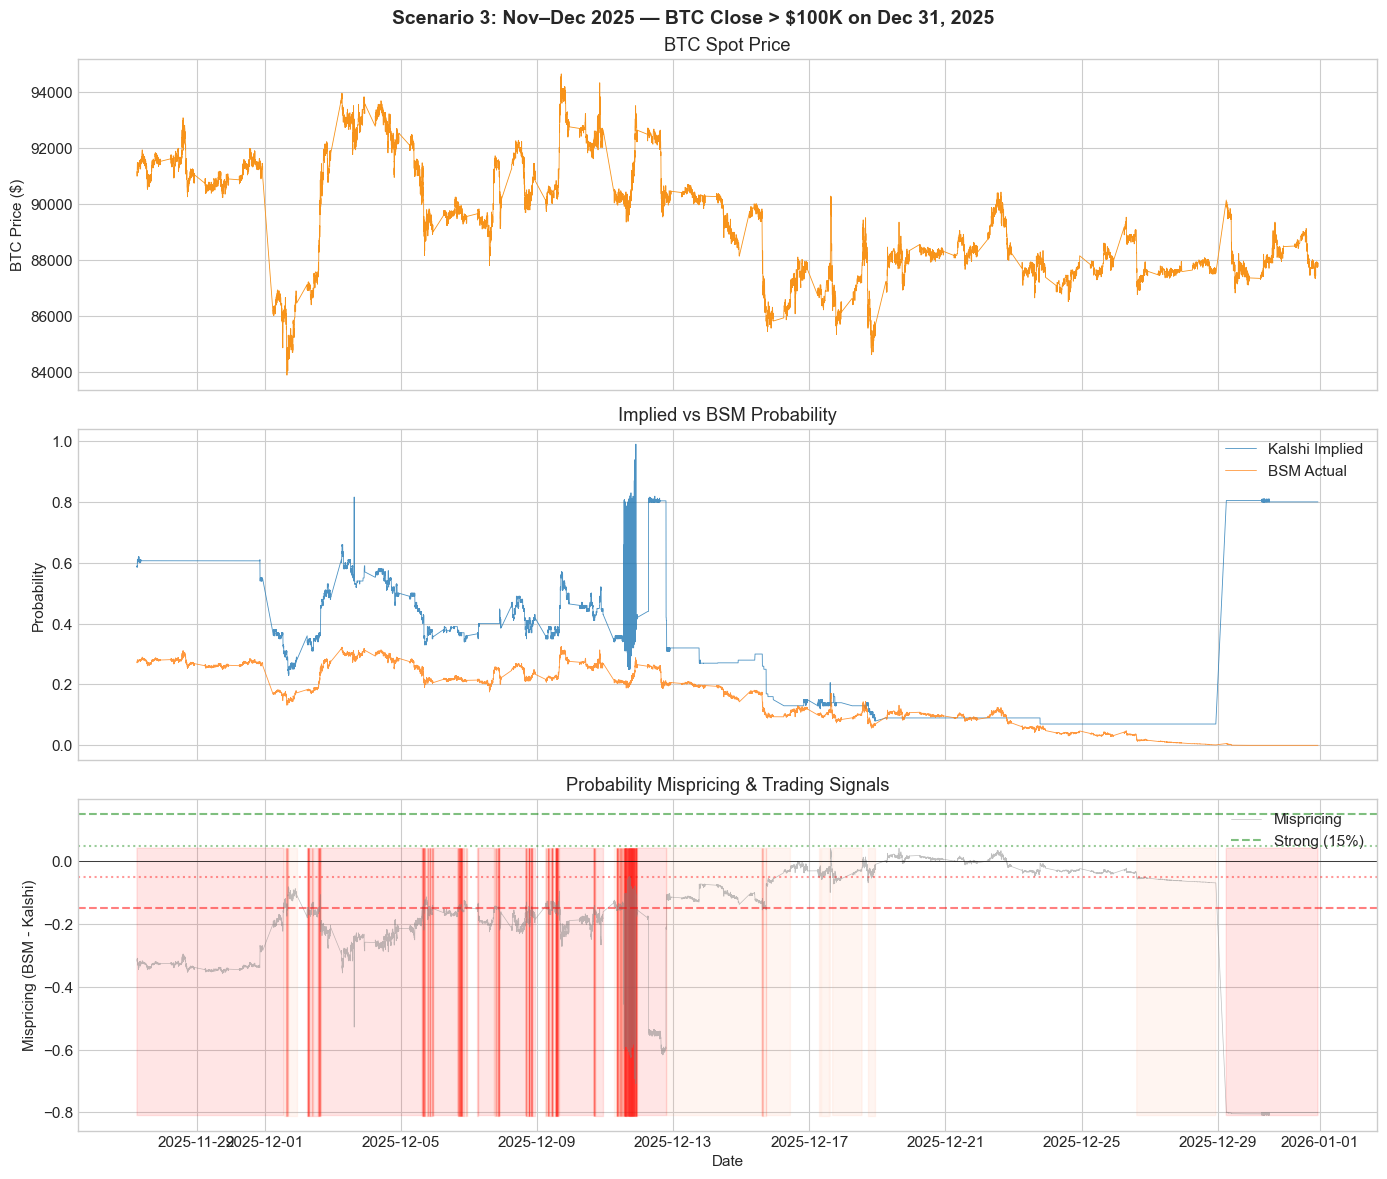

In [26]:
plot_scenario(res_dec25, 'Scenario 3: Nov–Dec 2025 — BTC Close > $100K on Dec 31, 2025')

---
## Scenario 4: Jan 2026 — Will BTC max reach $100K+ by Jan 31, 2026?

- **Kalshi market:** `kxbtcmaxmon-btc-26jan31` (BTC monthly max)
- **Strike:** $100,000
- **Expiry:** January 31, 2026
- **BTC data:** 1-min bars from Jan 2026 (fetched from Binance)
- **Thresholds:** strong=15%, weak=5%, neutral=2%

In [27]:
res_jan26 = run_backtest(
    kalshi_csv='kalshi-price-history-kxbtcmaxmon-btc-26jan31-minute.csv',
    btc_csv='BTC_1min_2026.csv',
    kalshi_col='Above $100000.00',
    strike=100000,
    expiry_date='2026-01-31',
    strong_thresh=0.15,
    weak_thresh=0.05,
    neutral_thresh=0.02,
)

summary_jan26 = print_results(res_jan26, 'SCENARIO 4: Jan 2026 — BTC Max ≥ $100K by Jan 31, 2026')

  SCENARIO 4: Jan 2026 — BTC Max ≥ $100K by Jan 31, 2026

  Data: 46,467 aligned 1-min bars
  Range: 2026-01-06 22:13:00 → 2026-02-08 04:39:00
  Mean implied prob:  18.28%
  Mean BSM prob:      13.12%
  Mean mispricing:    -5.15%
  Signal thresholds:  strong=15%  weak=5%  neutral=±2%
  Total trades:       109

  STRATEGY A: Unhedged BTC (Buy & Hold)
    Entry: $93,499.07  →  Exit: $69,174.52
    BTC Return: -26.02%
    P&L: $-2,601.58  (-26.02%)

  STRATEGY B: Static Hedge
    Kalshi entry (short Yes): 55.00%  →  exit: 1.00%
    Kalshi P&L:  $54.00
    Without fees: $-2,547.58  (-25.48%)
    With fees:    $-2,549.39  (-25.49%)   [fees: $1.81]

  STRATEGY C: Dynamic Hedge
    Kalshi P&L (no fees):  $179.68
    Total fees:            $160.15  (109 trades)
    Without fees: $-2,421.90  (-24.22%)
    With fees:    $-2,582.05  (-25.82%)

  — Summary Table —
        Strategy  P&L (no fees)  P&L (with fees) Return (no fees) Return (with fees)
     A: Unhedged   -2601.582026     -2601.582026  

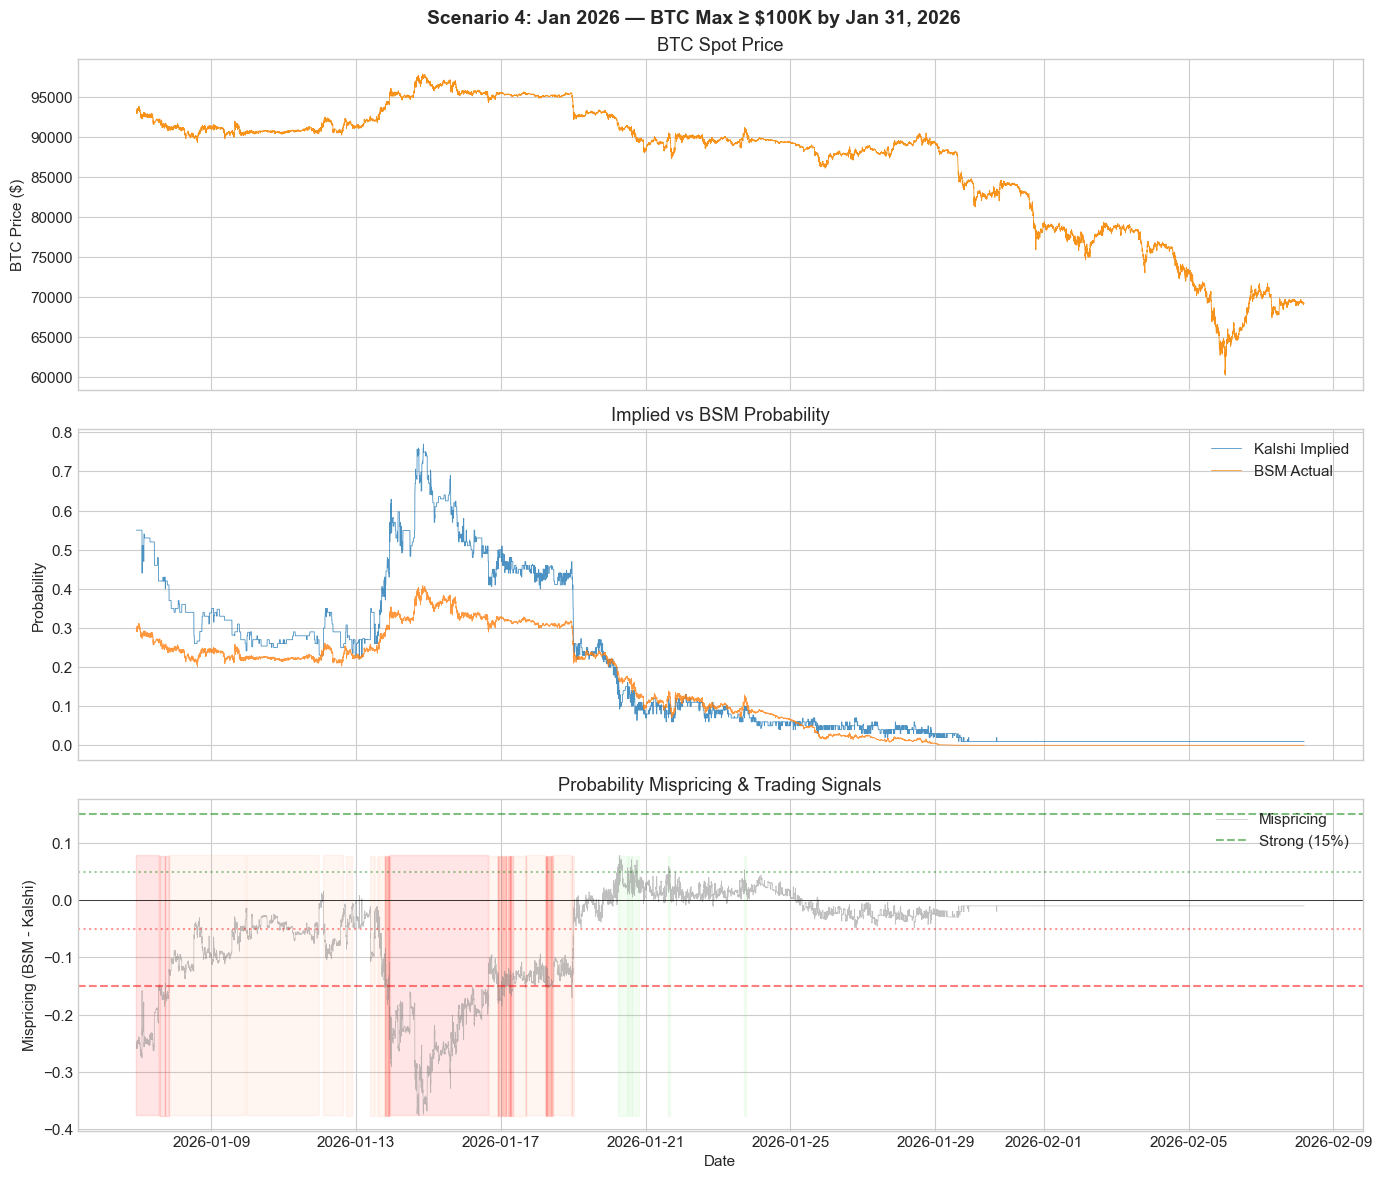

In [28]:
plot_scenario(res_jan26, 'Scenario 4: Jan 2026 — BTC Max ≥ $100K by Jan 31, 2026')

---
## Cross-Scenario Comparison

Side-by-side view of all four scenarios, with and without fees.

In [29]:
# Build a combined comparison table
scenarios = {
    '2024 ($100K max)': res_2024,
    'Aug 2025 ($130K max)': res_aug25,
    'Dec 2025 ($100K close)': res_dec25,
    'Jan 2026 ($100K max)': res_jan26,
}

rows = []
for name, r in scenarios.items():
    cap = r['initial_capital']
    rows.append({
        'Scenario': name,
        'BTC Return': f"{r['btc_return']:.2%}",
        'Unhedged P&L': f"${r['pnl_a']:,.2f}",
        'Static (no fees)': f"${r['pnl_b_no_fee']:,.2f}",
        'Static (w/ fees)': f"${r['pnl_b_fee']:,.2f}",
        'Dynamic (no fees)': f"${r['pnl_c_no_fee']:,.2f}",
        'Dynamic (w/ fees)': f"${r['pnl_c_fee']:,.2f}",
        'Trades': r['num_trades'],
        'Total Fees': f"${r['total_fees_c']:,.2f}",
    })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))

              Scenario BTC Return Unhedged P&L Static (no fees) Static (w/ fees) Dynamic (no fees) Dynamic (w/ fees)  Trades Total Fees
      2024 ($100K max)     43.60%    $4,359.70        $4,409.88        $4,407.26         $4,678.32         $4,354.99     221    $323.33
  Aug 2025 ($130K max)    -25.45%   $-2,545.33       $-2,623.10       $-2,624.35        $-2,543.32        $-2,548.32       5      $5.00
Dec 2025 ($100K close)     -3.58%     $-358.16         $-379.50         $-382.33         $2,469.05         $1,644.33     525    $824.72
  Jan 2026 ($100K max)    -26.02%   $-2,601.58       $-2,547.58       $-2,549.39        $-2,421.90        $-2,582.05     109    $160.15


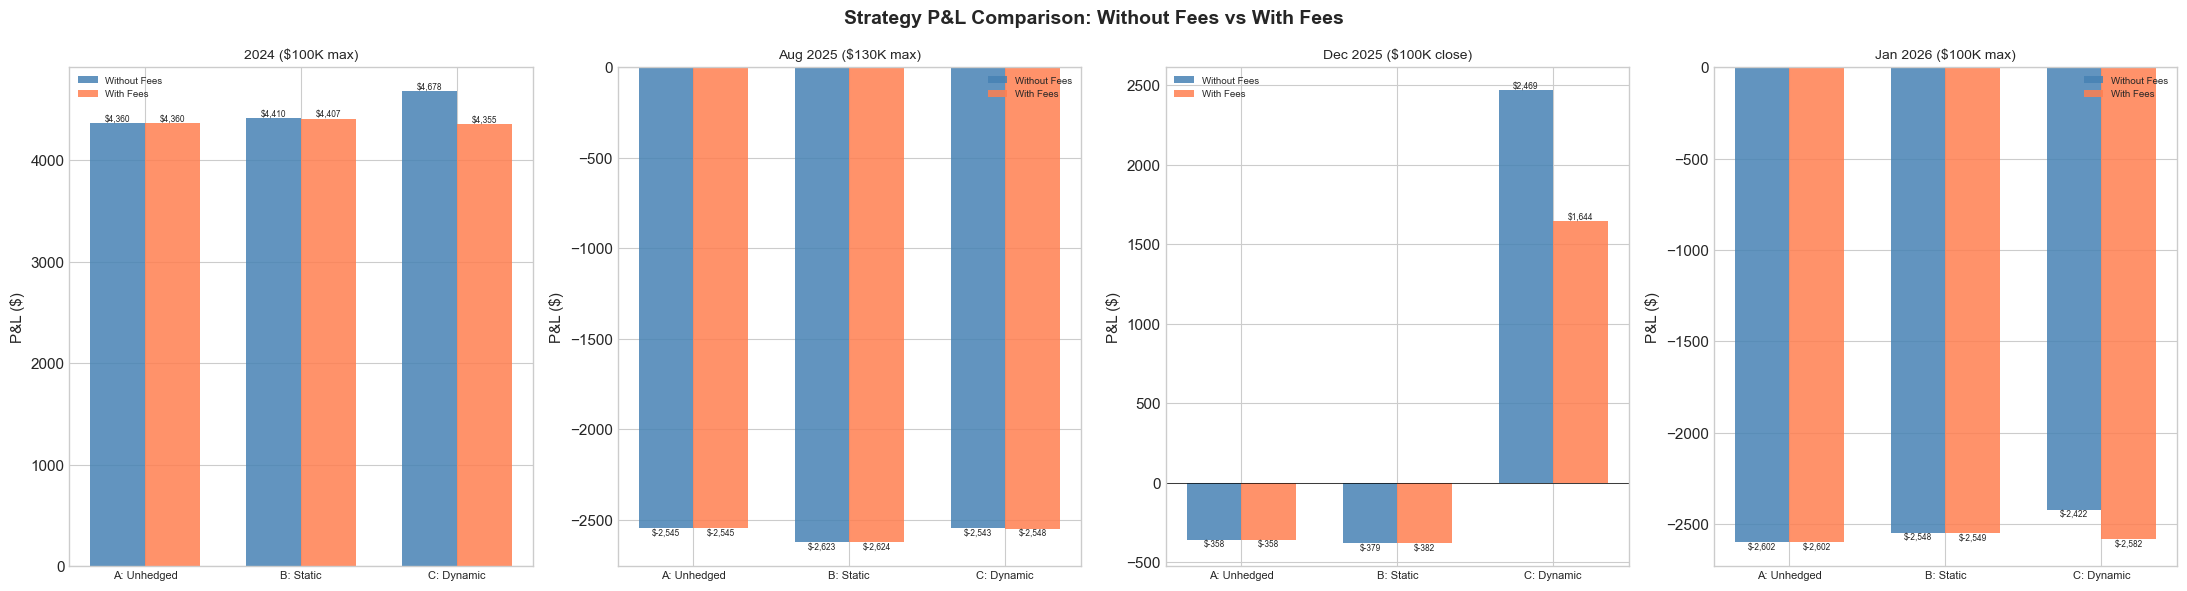

In [30]:
# Bar chart: P&L comparison across scenarios (with vs without fees)
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('Strategy P&L Comparison: Without Fees vs With Fees', fontsize=14, fontweight='bold')

for idx, (name, r) in enumerate(scenarios.items()):
    ax = axes[idx]
    strategies = ['A: Unhedged', 'B: Static', 'C: Dynamic']
    pnl_no_fee = [r['pnl_a'], r['pnl_b_no_fee'], r['pnl_c_no_fee']]
    pnl_fee    = [r['pnl_a'], r['pnl_b_fee'],    r['pnl_c_fee']]
    
    x = np.arange(len(strategies))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, pnl_no_fee, width, label='Without Fees', color='steelblue', alpha=0.85)
    bars2 = ax.bar(x + width/2, pnl_fee,    width, label='With Fees',    color='coral',     alpha=0.85)
    
    ax.set_title(name, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(strategies, fontsize=8)
    ax.set_ylabel('P&L ($)')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.legend(fontsize=7)
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:,.0f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=6)
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:,.0f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=6)

plt.tight_layout()
plt.show()

---
## Fee Impact Analysis

How much do Kalshi's fees (7% of notional x p(1-p) per trade) erode the dynamic hedge gains?

In [31]:
print(f"{'Scenario':<25} {'Trades':>7} {'Total Fees':>12} {'Gross Kalshi P&L':>18} {'Net Kalshi P&L':>16} {'Fee % of Gross':>16}")
print('-' * 96)

for name, r in scenarios.items():
    gross = r['kalshi_c_no_fee']
    fees  = r['total_fees_c']
    net   = r['kalshi_c_fee']
    pct   = (fees / abs(gross) * 100) if gross != 0 else 0
    print(f"{name:<25} {r['num_trades']:>7} ${fees:>10,.2f} ${gross:>16,.2f} ${net:>14,.2f} {pct:>14.1f}%")

Scenario                   Trades   Total Fees   Gross Kalshi P&L   Net Kalshi P&L   Fee % of Gross
------------------------------------------------------------------------------------------------
2024 ($100K max)              221 $    323.33 $          318.62 $         -4.71          101.5%
Aug 2025 ($130K max)            5 $      5.00 $            2.01 $         -2.99          248.8%
Dec 2025 ($100K close)        525 $    824.72 $        2,827.21 $      2,002.49           29.2%
Jan 2026 ($100K max)          109 $    160.15 $          179.68 $         19.53           89.1%


---
## Risk Metrics: Sharpe Ratio, Max Drawdown, VaR & CVaR

To properly evaluate each hedging strategy beyond raw P&L, we compute four key risk metrics on the **hourly returns** of each strategy's equity curve:

- **Sharpe Ratio** — Annualized return / annualized volatility (risk-free rate = 0). Higher is better.
- **Max Drawdown** — Largest peak-to-trough decline in equity. Measures worst-case pain.
- **VaR (95%)** — Value at Risk: the 5th-percentile hourly return. "In 95% of hours, you lose no more than this."
- **CVaR (95%)** — Conditional VaR (Expected Shortfall): the average loss in the worst 5% of hours. Captures tail risk beyond VaR.

In [32]:
def build_equity_curves(res):
    """
    Build minute-by-minute equity curves for all three strategies.
    
    Returns a DataFrame with columns: timestamp, equity_a, equity_b, equity_c_nofee, equity_c_fee
    
    Strategy A: capital * (btc_t / btc_0)
    Strategy B: Strategy A + mark-to-market on static Kalshi short Yes position
    Strategy C: Strategy A + running Kalshi P&L from dynamic signals (with & without fees)
    """
    df = res['df'].copy()
    cap = res['initial_capital']
    contracts = res['contracts']
    first_btc = res['first_btc']
    first_mkt = res['first_mkt']
    
    # Strategy A: unhedged BTC
    df['equity_a'] = cap * (df['btc_price'] / first_btc)
    
    # Strategy B: BTC + static short Yes (mark-to-market)
    # Short Yes at first_mkt → P&L at time t = (first_mkt - mkt_t) * contracts
    df['equity_b'] = df['equity_a'] + (first_mkt - df['market_price']) * contracts
    
    # Strategy C: BTC + dynamic Kalshi trades (track running P&L minute by minute)
    kalshi_running_pnl = np.zeros(len(df))
    fee_running = np.zeros(len(df))
    position = 0
    entry_price = 0.0
    cumulative_pnl = 0.0
    cumulative_fee = 0.0
    
    for i in range(1, len(df)):
        current_signal = df.iloc[i]['signal']
        current_price = df.iloc[i]['market_price']
        
        if position != current_signal:
            # Close existing position
            if position != 0:
                cumulative_pnl += (current_price - entry_price) * position * contracts
            # Fee on this trade
            if df.iloc[i]['trade']:
                cumulative_fee += np.ceil(
                    0.07 * contracts * current_price * (1 - current_price) * 100
                ) / 100
            position = current_signal
            entry_price = current_price
        
        # Mark-to-market: unrealized P&L on open position
        unrealized = 0.0
        if position != 0:
            unrealized = (current_price - entry_price) * position * contracts
        
        kalshi_running_pnl[i] = cumulative_pnl + unrealized
        fee_running[i] = cumulative_fee
    
    df['equity_c_nofee'] = df['equity_a'] + kalshi_running_pnl
    df['equity_c_fee']   = df['equity_a'] + kalshi_running_pnl - fee_running
    
    return df[['timestamp', 'equity_a', 'equity_b', 'equity_c_nofee', 'equity_c_fee']].copy()


def compute_risk_metrics(eq_df, col, hours_per_year=8760):
    """
    Compute Sharpe, Max Drawdown, VaR(95%), CVaR(95%) from an equity curve.
    
    Uses hourly returns (resample minute data to hourly) for more stable estimates.
    """
    # Resample to hourly (last price per hour)
    hourly = eq_df.set_index('timestamp')[[col]].resample('1h').last().dropna()
    returns = hourly[col].pct_change().dropna()
    
    if len(returns) < 2 or returns.std() == 0:
        return {'sharpe': 0.0, 'max_drawdown': 0.0, 'var_95': 0.0, 'cvar_95': 0.0}
    
    # Annualized Sharpe (rf=0)
    sharpe = (returns.mean() / returns.std()) * np.sqrt(hours_per_year)
    
    # Max Drawdown from the equity curve (use full minute data for precision)
    equity = eq_df[col].values
    running_max = np.maximum.accumulate(equity)
    drawdowns = (equity - running_max) / running_max
    max_dd = drawdowns.min()  # most negative = worst drawdown
    
    # VaR and CVaR at 95% confidence (on hourly returns)
    var_95 = np.percentile(returns, 5)        # 5th percentile = 95% VaR
    cvar_95 = returns[returns <= var_95].mean()  # average of worst 5%
    
    return {
        'sharpe': sharpe,
        'max_drawdown': max_dd,
        'var_95': var_95,
        'cvar_95': cvar_95,
    }


# Compute equity curves and risk metrics for all scenarios
all_risk = {}
all_equity = {}

for name, r in scenarios.items():
    eq = build_equity_curves(r)
    all_equity[name] = eq
    
    metrics = {}
    for strat, col in [('A: Unhedged', 'equity_a'), 
                        ('B: Static', 'equity_b'),
                        ('C: Dynamic (no fees)', 'equity_c_nofee'),
                        ('C: Dynamic (w/ fees)', 'equity_c_fee')]:
        metrics[strat] = compute_risk_metrics(eq, col)
    all_risk[name] = metrics

# Print risk metrics table
print(f"{'Scenario':<25} {'Strategy':<25} {'Sharpe':>8} {'Max DD':>9} {'VaR 95%':>10} {'CVaR 95%':>10}")
print('=' * 89)
for name in scenarios:
    for strat, m in all_risk[name].items():
        print(f"{name:<25} {strat:<25} {m['sharpe']:>8.2f} {m['max_drawdown']:>8.2%} {m['var_95']:>9.4%} {m['cvar_95']:>9.4%}")
    print('-' * 89)

Scenario                  Strategy                    Sharpe    Max DD    VaR 95%   CVaR 95%
2024 ($100K max)          A: Unhedged                   1.54  -30.98%  -0.9329%  -1.5607%
2024 ($100K max)          B: Static                     1.56  -30.68%  -0.9287%  -1.5523%
2024 ($100K max)          C: Dynamic (no fees)          1.64  -28.79%  -0.9130%  -1.5221%
2024 ($100K max)          C: Dynamic (w/ fees)          1.55  -29.15%  -0.9206%  -1.5387%
-----------------------------------------------------------------------------------------
Aug 2025 ($130K max)      A: Unhedged                  -1.57  -35.73%  -0.7858%  -1.3442%
Aug 2025 ($130K max)      B: Static                    -1.61  -35.99%  -0.7880%  -1.3560%
Aug 2025 ($130K max)      C: Dynamic (no fees)         -1.56  -35.72%  -0.7858%  -1.3440%
Aug 2025 ($130K max)      C: Dynamic (w/ fees)         -1.57  -35.74%  -0.7861%  -1.3448%
-----------------------------------------------------------------------------------------
Dec 202

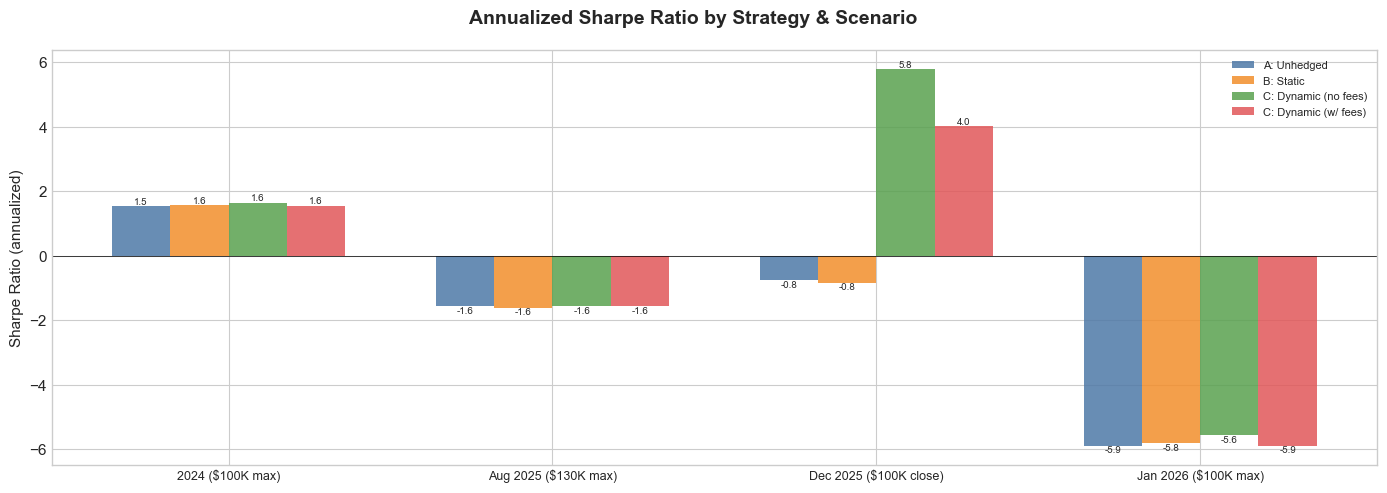

In [33]:
# --- Sharpe Ratio Comparison (grouped bar chart) ---
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Annualized Sharpe Ratio by Strategy & Scenario', fontsize=14, fontweight='bold')

scenario_names = list(scenarios.keys())
strat_names = ['A: Unhedged', 'B: Static', 'C: Dynamic (no fees)', 'C: Dynamic (w/ fees)']
colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']

x = np.arange(len(scenario_names))
width = 0.18

for j, (strat, color) in enumerate(zip(strat_names, colors)):
    vals = [all_risk[s][strat]['sharpe'] for s in scenario_names]
    bars = ax.bar(x + j * width - 1.5 * width, vals, width, label=strat, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.1f}',
                ha='center', va='bottom' if h >= 0 else 'top', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(scenario_names, fontsize=9)
ax.set_ylabel('Sharpe Ratio (annualized)')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()

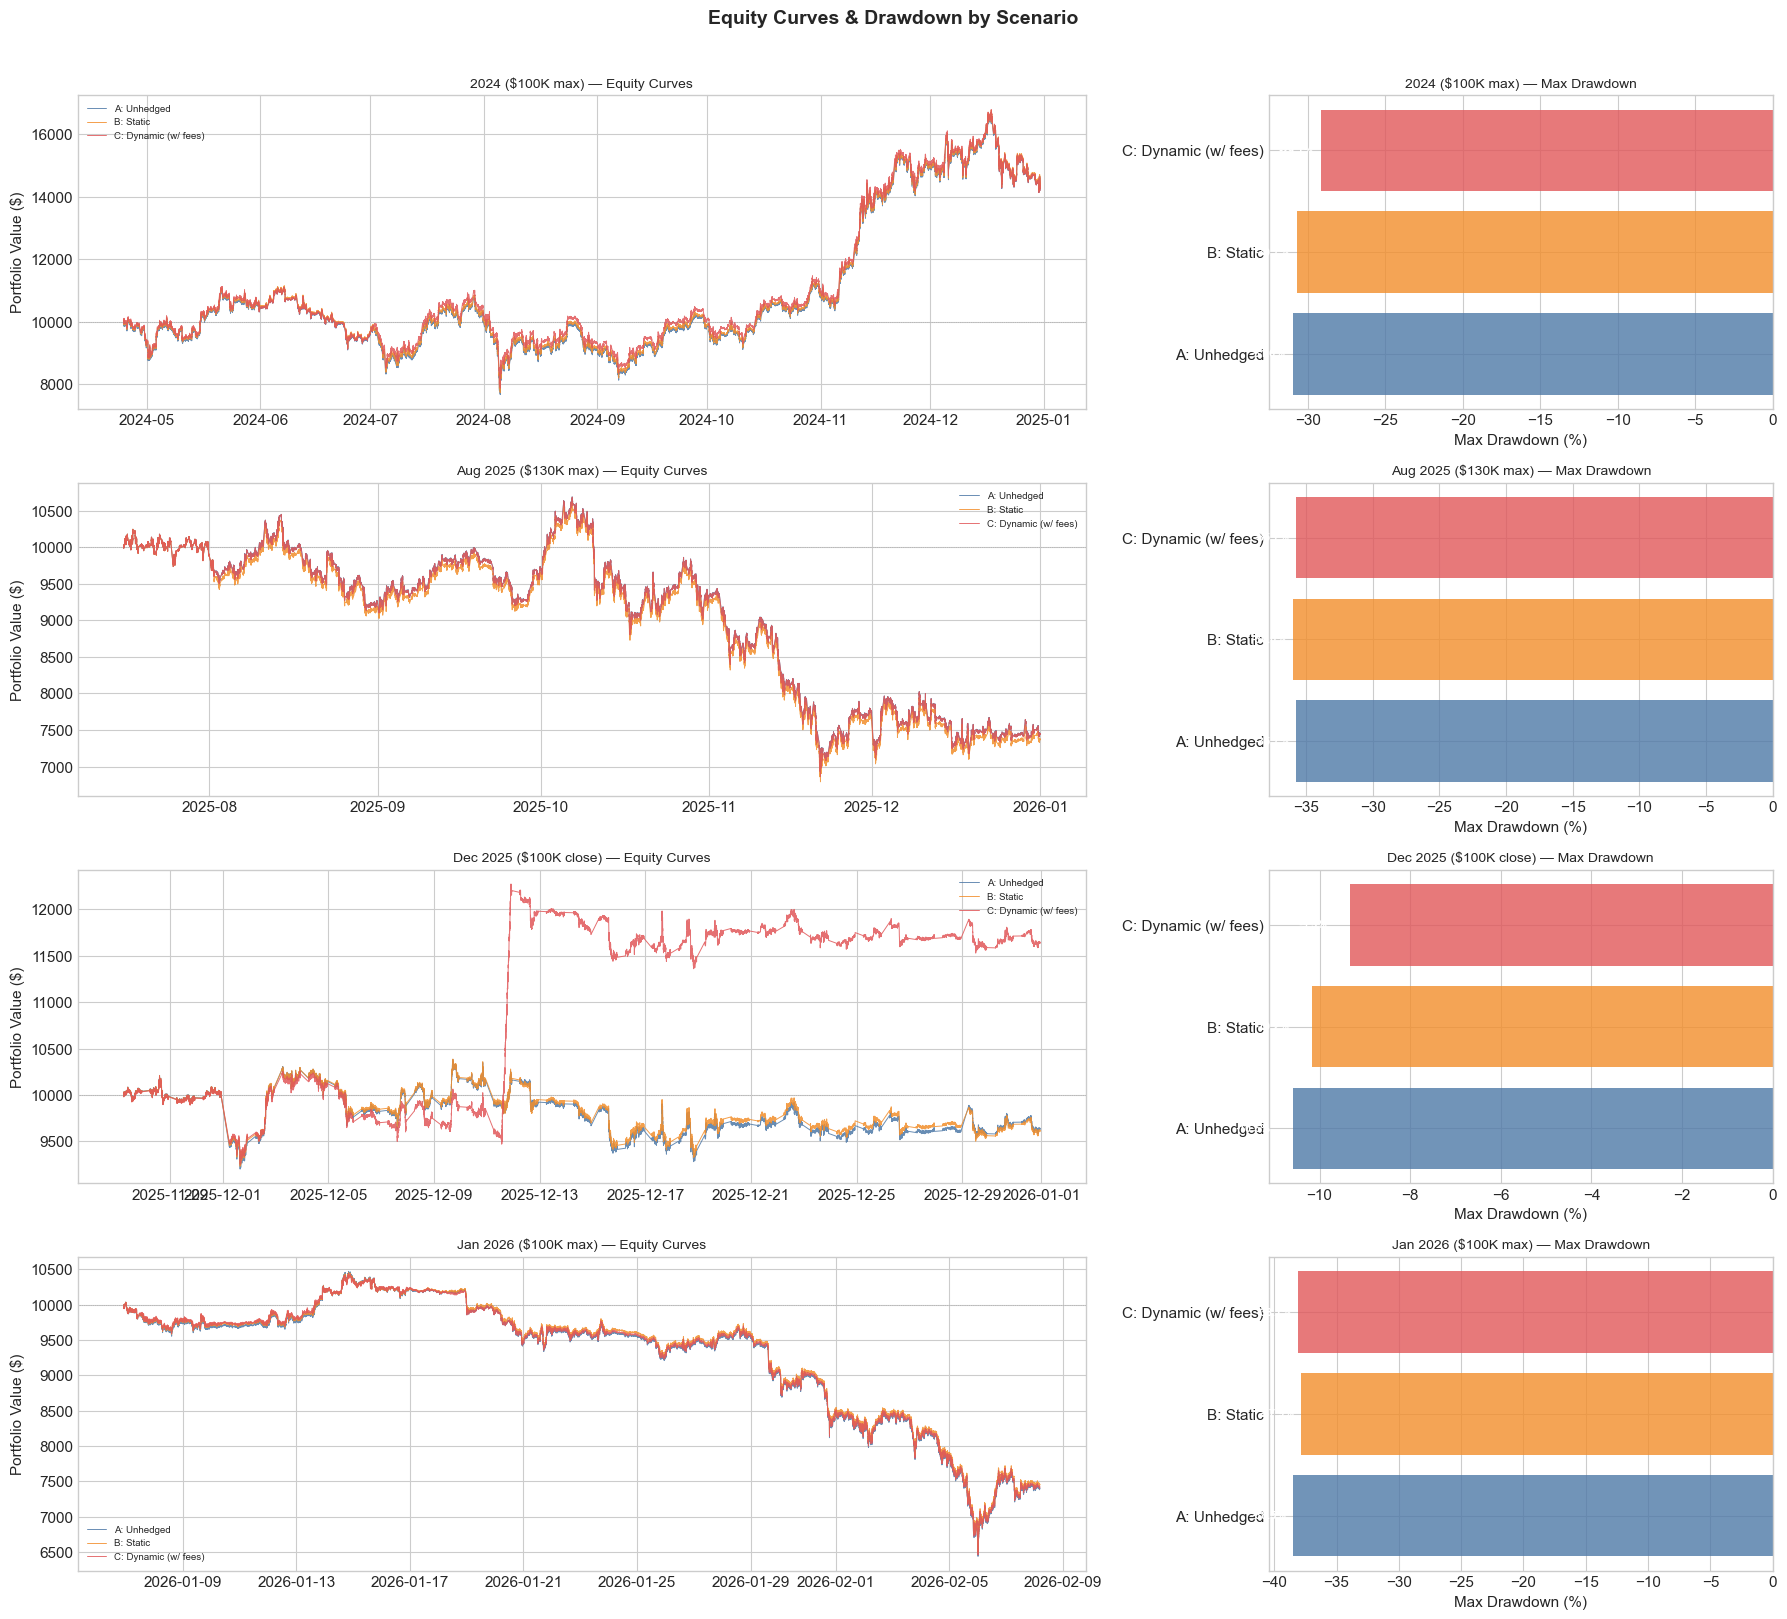

In [34]:
# --- Max Drawdown: Equity curves + drawdown shading ---
fig, axes = plt.subplots(len(scenarios), 2, figsize=(18, 4 * len(scenarios)), 
                          gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle('Equity Curves & Drawdown by Scenario', fontsize=14, fontweight='bold', y=1.01)

strat_cols = [('equity_a', 'A: Unhedged', '#4e79a7'),
              ('equity_b', 'B: Static', '#f28e2b'),
              ('equity_c_fee', 'C: Dynamic (w/ fees)', '#e15759')]

for idx, (name, _) in enumerate(scenarios.items()):
    eq = all_equity[name]
    ax_eq = axes[idx, 0]
    ax_dd = axes[idx, 1]
    
    # Left panel: equity curves
    for col, label, color in strat_cols:
        ax_eq.plot(eq['timestamp'], eq[col], label=label, color=color, linewidth=0.7, alpha=0.85)
    ax_eq.axhline(y=10000, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
    ax_eq.set_ylabel('Portfolio Value ($)')
    ax_eq.set_title(f'{name} — Equity Curves', fontsize=10)
    ax_eq.legend(fontsize=7, loc='best')
    
    # Right panel: drawdown comparison (bar chart of max drawdowns)
    dd_vals = []
    dd_labels = []
    dd_colors = []
    for col, label, color in strat_cols:
        equity = eq[col].values
        running_max = np.maximum.accumulate(equity)
        dd = ((equity - running_max) / running_max).min()
        dd_vals.append(dd * 100)  # as percentage
        dd_labels.append(label)
        dd_colors.append(color)
    
    bars = ax_dd.barh(dd_labels, dd_vals, color=dd_colors, alpha=0.8)
    ax_dd.set_xlabel('Max Drawdown (%)')
    ax_dd.set_title(f'{name} — Max Drawdown', fontsize=10)
    for bar, val in zip(bars, dd_vals):
        ax_dd.text(val - 0.5, bar.get_y() + bar.get_height()/2., 
                   f'{val:.1f}%', va='center', ha='right', fontsize=8, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

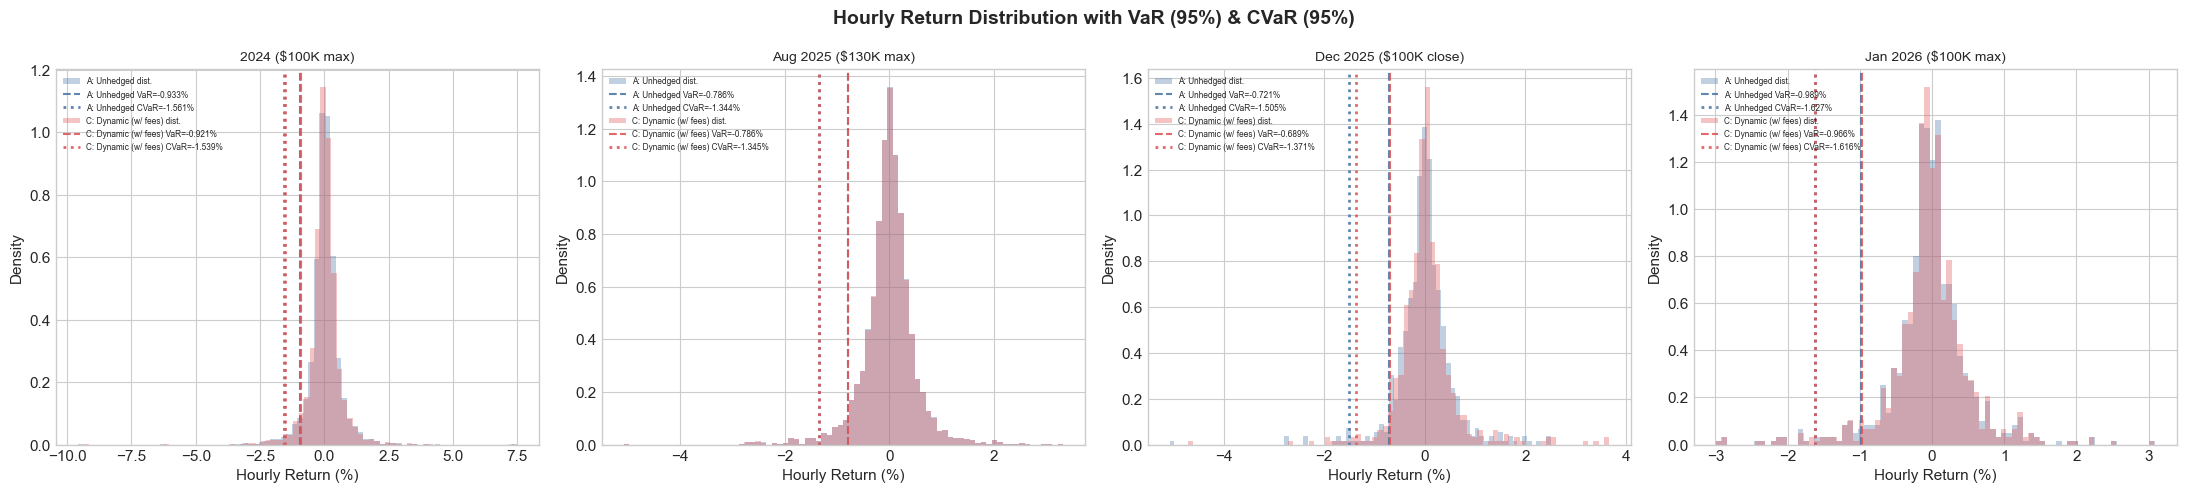

In [35]:
# --- VaR & CVaR: Hourly return distributions + tail risk markers ---
fig, axes = plt.subplots(1, len(scenarios), figsize=(5.5 * len(scenarios), 5))
fig.suptitle('Hourly Return Distribution with VaR (95%) & CVaR (95%)', fontsize=14, fontweight='bold')

for idx, (name, _) in enumerate(scenarios.items()):
    ax = axes[idx]
    eq = all_equity[name]
    
    for col, label, color, ls in [('equity_a', 'A: Unhedged', '#4e79a7', '-'),
                                   ('equity_c_fee', 'C: Dynamic (w/ fees)', '#e15759', '--')]:
        # Compute hourly returns
        hourly = eq.set_index('timestamp')[[col]].resample('1h').last().dropna()
        returns = hourly[col].pct_change().dropna() * 100  # in percent
        
        # Histogram
        ax.hist(returns, bins=80, alpha=0.35, color=color, density=True, label=f'{label} dist.')
        
        # VaR and CVaR lines
        var_val = np.percentile(returns, 5)
        cvar_val = returns[returns <= var_val].mean()
        
        ax.axvline(var_val, color=color, linestyle='--', linewidth=1.5, alpha=0.9,
                   label=f'{label} VaR={var_val:.3f}%')
        ax.axvline(cvar_val, color=color, linestyle=':', linewidth=2, alpha=0.9,
                   label=f'{label} CVaR={cvar_val:.3f}%')
    
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Hourly Return (%)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=6, loc='upper left')

plt.tight_layout()
plt.show()

---
## Key Takeaways

1. **Mispricing exists** — BSM-implied probabilities consistently diverge from Kalshi's market-implied prices, creating exploitable windows.
2. **Dynamic hedging can outperform** static hedges and pure buy-and-hold, but performance is scenario-dependent.
3. **Fees matter** — Kalshi's 7% fee on notional x p(1-p) per trade can significantly erode gains in high-frequency signal regimes. Fewer, higher-conviction trades are more fee-efficient.
4. **Threshold sensitivity** — The 2024 scenario uses wider thresholds (25/15/5%) reflecting greater uncertainty for a longer-dated contract. Tighter thresholds (15/5/2%) suit shorter-dated or closer-to-ATM markets.
5. **Black-Scholes limitations** — Crypto volatility is not constant; the BSM model is a rough approximation. Realized vol spikes can create false signals.